In [1]:
%pwd


'C:\\Users\\anura\\Downloads\\DATA601-Project\\notebooks'

In [6]:
# Change directory so everything is relative to the project root
%cd C:/Users/anura/Downloads/DATA601-Project

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)

print("Current working directory:", os.getcwd())


C:\Users\anura\Downloads\DATA601-Project
Current working directory: C:\Users\anura\Downloads\DATA601-Project


In [7]:
# Project paths
project_root = os.getcwd()  # should be the DATA601-Project folder

raw_path = os.path.join(
    project_root,
    "data_raw",
    "buoys",
    "PegasusBay_buoy-31020-wave-data-1712665470-1763407200.csv"
)

clean_path = os.path.join(
    project_root,
    "data_processed",
    "PegasusBay_buoy_clean.csv"
)

print("Raw path:   ", raw_path)
print("Clean path: ", clean_path)

# Make sure processed folder exists
os.makedirs(os.path.join(project_root, "data_processed"), exist_ok=True)

# Check that the raw file is actually found
print("Raw file exists?", os.path.exists(raw_path))


Raw path:    C:\Users\anura\Downloads\DATA601-Project\data_raw\buoys\PegasusBay_buoy-31020-wave-data-1712665470-1763407200.csv
Clean path:  C:\Users\anura\Downloads\DATA601-Project\data_processed\PegasusBay_buoy_clean.csv
Raw file exists? True


In [8]:
# Load just a few rows to check structure
df_head = pd.read_csv(raw_path, nrows=5)
df_head


,Time (UNIX/UTC),Timestamp (UTC),Site,BuoyID,Hsig (m),Tp (s),Tm (s),Dp (deg),DpSpr (deg),Dm (deg),...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,1712669070,2024-04-09T13:24:30.000Z,SPOT-31020C,SPOT-31020C,1.32,7.88,4.90,58.961,26.749,52.714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1712672670,2024-04-09T14:24:30.000Z,SPOT-31020C,SPOT-31020C,1.34,7.88,4.96,57.969,21.884,51.613,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1712676270,2024-04-09T15:24:30.000Z,SPOT-31020C,SPOT-31020C,1.34,7.88,5.20,55.614,23.537,53.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1712679870,2024-04-09T16:24:30.000Z,SPOT-31020C,SPOT-31020C,1.25,7.88,5.18,54.888,23.241,53.431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1712683470,2024-04-09T17:24:30.000Z,SPOT-31020C,SPOT-31020C,1.10,7.88,5.14,62.259,26.304,56.090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = pd.read_csv(raw_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (13227, 40)

Columns:
['Time (UNIX/UTC)', 'Timestamp (UTC)', 'Site', 'BuoyID', 'Hsig (m)', 'Tp (s)', 'Tm (s)', 'Dp (deg)', 'DpSpr (deg)', 'Dm (deg)', 'DmSpr (deg)', 'QF_waves', 'WindSpeed (m/s)', 'WindDirec (deg)', 'CurrmentMag (m/s)', 'CurrentDir (deg)', 'Latitude (deg)', 'Longitude (deg) ', 'buoy_id', 'seasurfaceId', 'processing_source', 'SST (degC)', 'QF_sst', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39']


In [10]:
# Convert Timestamp (UTC) to proper datetime and use as index
df["time"] = pd.to_datetime(df["Timestamp (UTC)"], utc=True, errors="coerce")

print("Unparsed timestamps:", df["time"].isna().sum())

# Drop any rows with invalid time
df = df.dropna(subset=["time"])

# Sort by time and set index
df = df.sort_values("time").set_index("time")

df.head()


Unparsed timestamps: 0


,Time (UNIX/UTC),Timestamp (UTC),Site,BuoyID,Hsig (m),Tp (s),Tm (s),Dp (deg),DpSpr (deg),Dm (deg),...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
time,,,,,,,,,,,,,,,,,,,,,
2024-04-09 13:24:30+00:00,1712669070,2024-04-09T13:24:30.000Z,SPOT-31020C,SPOT-31020C,1.32,7.88,4.90,58.961,26.749,52.714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-09 14:24:30+00:00,1712672670,2024-04-09T14:24:30.000Z,SPOT-31020C,SPOT-31020C,1.34,7.88,4.96,57.969,21.884,51.613,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-09 15:24:30+00:00,1712676270,2024-04-09T15:24:30.000Z,SPOT-31020C,SPOT-31020C,1.34,7.88,5.20,55.614,23.537,53.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-09 16:24:30+00:00,1712679870,2024-04-09T16:24:30.000Z,SPOT-31020C,SPOT-31020C,1.25,7.88,5.18,54.888,23.241,53.431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-09 17:24:30+00:00,1712683470,2024-04-09T17:24:30.000Z,SPOT-31020C,SPOT-31020C,1.10,7.88,5.14,62.259,26.304,56.090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Quick overview of missing values for key columns
key_cols = [c for c in ["Hsig (m)", "Tp (s)", "Tm (s)", "Dp (deg)", "QF_waves"] if c in df.columns]
df[key_cols].isna().mean().sort_values()


Hsig (m)    0.0
Tp (s)      0.0
Tm (s)      0.0
Dp (deg)    0.0
QF_waves    0.0
dtype: float64

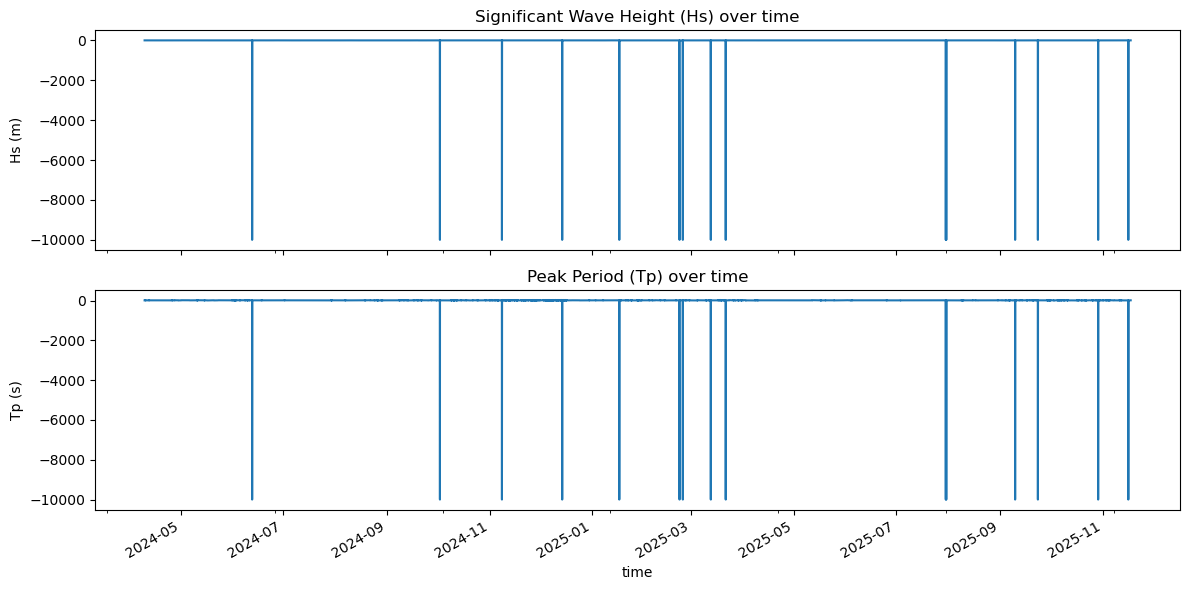

In [12]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

if "Hsig (m)" in df.columns:
    df["Hsig (m)"].plot(ax=axes[0])
    axes[0].set_ylabel("Hs (m)")
    axes[0].set_title("Significant Wave Height (Hs) over time")
else:
    axes[0].text(0.5, 0.5, "Hsig (m) column not found", ha="center", va="center")
    
if "Tp (s)" in df.columns:
    df["Tp (s)"].plot(ax=axes[1])
    axes[1].set_ylabel("Tp (s)")
    axes[1].set_title("Peak Period (Tp) over time")
else:
    axes[1].text(0.5, 0.5, "Tp (s) column not found", ha="center", va="center")

plt.tight_layout()
plt.show()


In [13]:
# Choose a core set of columns for now
core_cols = [
    "Site",
    "BuoyID",
    "Hsig (m)",
    "Tp (s)",
    "Tm (s)",
    "Dp (deg)",
    "DpSpr (deg)",
    "Dm (deg)",
    "DmSpr (deg)",
    "QF_waves",
    "WindSpeed (m/s)",
    "WindDirec (deg)",
]

core_cols = [c for c in core_cols if c in df.columns]

df_core = df[core_cols].copy()

df_core.to_csv(clean_path)
print("Saved cleaned file to:", clean_path)


Saved cleaned file to: C:\Users\anura\Downloads\DATA601-Project\data_processed\PegasusBay_buoy_clean.csv


In [19]:
df.columns.tolist()


['Time (UNIX/UTC)',
 'Timestamp (UTC)',
 'Site',
 'BuoyID',
 'Hsig (m)',
 'Tp (s)',
 'Tm (s)',
 'Dp (deg)',
 'DpSpr (deg)',
 'Dm (deg)',
 'DmSpr (deg)',
 'QF_waves',
 'WindSpeed (m/s)',
 'WindDirec (deg)',
 'CurrmentMag (m/s)',
 'CurrentDir (deg)',
 'Latitude (deg)',
 'Longitude (deg) ',
 'buoy_id',
 'seasurfaceId',
 'processing_source',
 'SST (degC)',
 'QF_sst',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'Unnamed: 26',
 'Unnamed: 27',
 'Unnamed: 28',
 'Unnamed: 29',
 'Unnamed: 30',
 'Unnamed: 31',
 'Unnamed: 32',
 'Unnamed: 33',
 'Unnamed: 34',
 'Unnamed: 35',
 'Unnamed: 36',
 'Unnamed: 37',
 'Unnamed: 38',
 'Unnamed: 39']

In [20]:
df["QF_waves"].value_counts(dropna=False)


QF_waves
1    13227
Name: count, dtype: int64

In [21]:
# Remove unnamed junk columns
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

# Keep only important columns going forward
cols_keep = [
    "Site",
    "BuoyID",
    "Hsig (m)",
    "Tp (s)",
    "Tm (s)",
    "Dp (deg)",
    "DpSpr (deg)",
    "Dm (deg)",
    "DmSpr (deg)",
    "WindSpeed (m/s)",
    "WindDirec (deg)",
    "SST (degC)"
]
cols_keep = [c for c in cols_keep if c in df.columns]

df = df[cols_keep]

# Show cleaned structure
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13227 entries, 2024-04-09 13:24:30+00:00 to 2025-11-17 18:20:00+00:00
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Site             13227 non-null  object 
 1   BuoyID           13227 non-null  object 
 2   Hsig (m)         13227 non-null  float64
 3   Tp (s)           13227 non-null  float64
 4   Tm (s)           13227 non-null  float64
 5   Dp (deg)         13227 non-null  float64
 6   DpSpr (deg)      13227 non-null  float64
 7   Dm (deg)         13227 non-null  float64
 8   DmSpr (deg)      13227 non-null  float64
 9   WindSpeed (m/s)  13227 non-null  float64
 10  WindDirec (deg)  13227 non-null  int64  
 11  SST (degC)       13227 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 1.3+ MB


,Site,BuoyID,Hsig (m),Tp (s),Tm (s),Dp (deg),DpSpr (deg),Dm (deg),DmSpr (deg),WindSpeed (m/s),WindDirec (deg),SST (degC)
time,,,,,,,,,,,,
2024-04-09 13:24:30+00:00,SPOT-31020C,SPOT-31020C,1.32,7.88,4.90,58.961,26.749,52.714,51.744,9.2,342,14.9
2024-04-09 14:24:30+00:00,SPOT-31020C,SPOT-31020C,1.34,7.88,4.96,57.969,21.884,51.613,48.464,9.6,257,14.88
2024-04-09 15:24:30+00:00,SPOT-31020C,SPOT-31020C,1.34,7.88,5.20,55.614,23.537,53.875,46.087,8.8,337,14.82
2024-04-09 16:24:30+00:00,SPOT-31020C,SPOT-31020C,1.25,7.88,5.18,54.888,23.241,53.431,43.849,8.0,337,14.74
2024-04-09 17:24:30+00:00,SPOT-31020C,SPOT-31020C,1.10,7.88,5.14,62.259,26.304,56.090,43.794,7.2,342,14.7


In [22]:
df["Hsig (m)"].describe()


count    13227.000000
mean       -11.040716
std        347.604759
min      -9999.000000
25%          0.750000
50%          0.940000
75%          1.220000
max          4.510000
Name: Hsig (m), dtype: float64

In [23]:
# Replace invalid values with NaN
df["Hsig (m)"] = df["Hsig (m)"].replace([-9999, -999, -99], np.nan)

# Remove negative or zero waves (non-physical)
df = df[df["Hsig (m)"] > 0]

df["Hsig (m)"].describe()


count    13211.000000
mean         1.055821
std          0.465103
min          0.360000
25%          0.750000
50%          0.940000
75%          1.220000
max          4.510000
Name: Hsig (m), dtype: float64

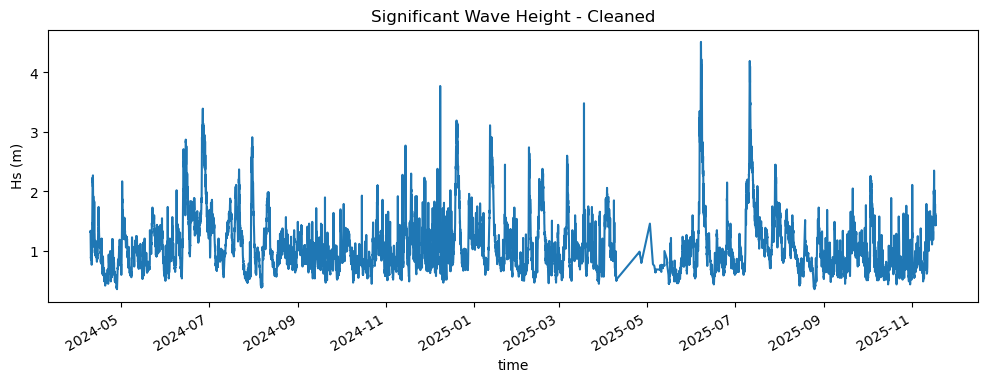

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
df["Hsig (m)"].plot(ax=ax)
ax.set_ylabel("Hs (m)")
ax.set_title("Significant Wave Height - Cleaned")
plt.show()


In [25]:
storm_threshold = 2.5
df["storm"] = df["Hsig (m)"] > storm_threshold
df["storm"].value_counts()


storm
False    12964
True       247
Name: count, dtype: int64

In [26]:
storms = []
in_storm = False

for i in range(len(df)):
    if df["storm"].iloc[i] and not in_storm:
        # storm begins
        start = df.index[i]
        in_storm = True
    elif not df["storm"].iloc[i] and in_storm:
        # storm ends
        end = df.index[i-1]
        storms.append((start, end))
        in_storm = False

# Handle case where last point is in a storm
if in_storm:
    storms.append((start, df.index[-1]))

storms[:10], len(storms)


([(Timestamp('2024-06-13 05:40:00+0000', tz='UTC'),
   Timestamp('2024-06-13 08:40:00+0000', tz='UTC')),
  (Timestamp('2024-06-14 16:40:00+0000', tz='UTC'),
   Timestamp('2024-06-14 22:40:00+0000', tz='UTC')),
  (Timestamp('2024-06-15 00:40:00+0000', tz='UTC'),
   Timestamp('2024-06-15 06:40:00+0000', tz='UTC')),
  (Timestamp('2024-06-25 23:45:00+0000', tz='UTC'),
   Timestamp('2024-06-27 12:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-27 14:45:00+0000', tz='UTC'),
   Timestamp('2024-06-27 19:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-27 21:45:00+0000', tz='UTC'),
   Timestamp('2024-06-27 21:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-27 23:45:00+0000', tz='UTC'),
   Timestamp('2024-06-28 04:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-28 07:45:00+0000', tz='UTC'),
   Timestamp('2024-06-28 07:45:00+0000', tz='UTC')),
  (Timestamp('2024-07-30 11:55:00+0000', tz='UTC'),
   Timestamp('2024-07-30 12:55:00+0000', tz='UTC')),
  (Timestamp('2024-07-30 16:55:00+0000', tz='UTC'),
   

In [27]:
storm_events = []

for start, end in storms:
    event = df.loc[start:end]
    storm_events.append({
        "start": start,
        "end": end,
        "duration_hours": (end - start).total_seconds() / 3600,
        "peak_Hs": event["Hsig (m)"].max(),
        "mean_Hs": event["Hsig (m)"].mean()
    })

storm_df = pd.DataFrame(storm_events)
storm_df.sort_values(by="peak_Hs", ascending=False).head(10)


,start,end,duration_hours,peak_Hs,mean_Hs
25,2025-06-06 15:45:00+00:00,2025-06-08 14:45:00+00:00,47.000000,4.51,3.346875
28,2025-07-11 02:50:00+00:00,2025-07-12 14:50:00+00:00,36.000000,4.19,3.274865
11,2024-12-08 11:45:00+00:00,2024-12-08 11:45:00+00:00,0.000000,3.77,3.770000
24,2025-03-18 07:40:00+00:00,2025-03-18 08:40:00+00:00,1.000000,3.48,3.235000
3,2024-06-25 23:45:00+00:00,2024-06-27 12:45:00+00:00,37.000000,3.39,2.933947
13,2024-12-19 11:30:00+00:00,2024-12-20 18:30:00+00:00,31.000000,3.19,2.847500
14,2025-01-11 23:40:00+00:00,2025-01-12 07:40:00+00:00,8.000000,3.11,2.828889
4,2024-06-27 14:45:00+00:00,2024-06-27 19:45:00+00:00,5.000000,2.95,2.778333
16,2025-01-13 02:40:00+00:00,2025-01-13 09:40:00+00:00,7.000000,2.91,2.701250
9,2024-07-30 16:55:00+00:00,2024-07-31 04:00:00+00:00,11.083333,2.91,2.671667


In [28]:
df["storm"].value_counts()


storm
False    12964
True       247
Name: count, dtype: int64

In [29]:
storms[:10], len(storms)


([(Timestamp('2024-06-13 05:40:00+0000', tz='UTC'),
   Timestamp('2024-06-13 08:40:00+0000', tz='UTC')),
  (Timestamp('2024-06-14 16:40:00+0000', tz='UTC'),
   Timestamp('2024-06-14 22:40:00+0000', tz='UTC')),
  (Timestamp('2024-06-15 00:40:00+0000', tz='UTC'),
   Timestamp('2024-06-15 06:40:00+0000', tz='UTC')),
  (Timestamp('2024-06-25 23:45:00+0000', tz='UTC'),
   Timestamp('2024-06-27 12:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-27 14:45:00+0000', tz='UTC'),
   Timestamp('2024-06-27 19:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-27 21:45:00+0000', tz='UTC'),
   Timestamp('2024-06-27 21:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-27 23:45:00+0000', tz='UTC'),
   Timestamp('2024-06-28 04:45:00+0000', tz='UTC')),
  (Timestamp('2024-06-28 07:45:00+0000', tz='UTC'),
   Timestamp('2024-06-28 07:45:00+0000', tz='UTC')),
  (Timestamp('2024-07-30 11:55:00+0000', tz='UTC'),
   Timestamp('2024-07-30 12:55:00+0000', tz='UTC')),
  (Timestamp('2024-07-30 16:55:00+0000', tz='UTC'),
   

In [30]:
storm_df.sort_values(by="peak_Hs", ascending=False).head(10)


,start,end,duration_hours,peak_Hs,mean_Hs
25,2025-06-06 15:45:00+00:00,2025-06-08 14:45:00+00:00,47.000000,4.51,3.346875
28,2025-07-11 02:50:00+00:00,2025-07-12 14:50:00+00:00,36.000000,4.19,3.274865
11,2024-12-08 11:45:00+00:00,2024-12-08 11:45:00+00:00,0.000000,3.77,3.770000
24,2025-03-18 07:40:00+00:00,2025-03-18 08:40:00+00:00,1.000000,3.48,3.235000
3,2024-06-25 23:45:00+00:00,2024-06-27 12:45:00+00:00,37.000000,3.39,2.933947
13,2024-12-19 11:30:00+00:00,2024-12-20 18:30:00+00:00,31.000000,3.19,2.847500
14,2025-01-11 23:40:00+00:00,2025-01-12 07:40:00+00:00,8.000000,3.11,2.828889
4,2024-06-27 14:45:00+00:00,2024-06-27 19:45:00+00:00,5.000000,2.95,2.778333
16,2025-01-13 02:40:00+00:00,2025-01-13 09:40:00+00:00,7.000000,2.91,2.701250
9,2024-07-30 16:55:00+00:00,2024-07-31 04:00:00+00:00,11.083333,2.91,2.671667


In [31]:
for start, end in storms:
    event = df.loc[start:end]
    storm_events.append({
        "start": start,
        "end": end,
        "duration_hours": (end - start).total_seconds() / 3600,
        "peak_Hs": event["Hsig (m)"].max(),
        "mean_Hs": event["Hsig (m)"].mean(),
        "mean_Tp": event["Tp (s)"].mean(),
        "mean_direction": event["Dp (deg)"].mean()
    })

storm_df = pd.DataFrame(storm_events)
storm_df.head()


,start,end,duration_hours,peak_Hs,mean_Hs,mean_Tp,mean_direction
0,2024-06-13 05:40:00+00:00,2024-06-13 08:40:00+00:00,3.0,2.71,2.582500,NaN,NaN
1,2024-06-14 16:40:00+00:00,2024-06-14 22:40:00+00:00,6.0,2.87,2.770000,NaN,NaN
2,2024-06-15 00:40:00+00:00,2024-06-15 06:40:00+00:00,6.0,2.76,2.648571,NaN,NaN
3,2024-06-25 23:45:00+00:00,2024-06-27 12:45:00+00:00,37.0,3.39,2.933947,NaN,NaN
4,2024-06-27 14:45:00+00:00,2024-06-27 19:45:00+00:00,5.0,2.95,2.778333,NaN,NaN


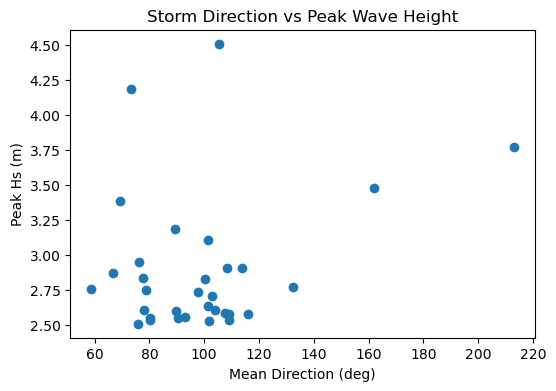

In [32]:
plt.figure(figsize=(6,4))
plt.scatter(storm_df["mean_direction"], storm_df["peak_Hs"])
plt.xlabel("Mean Direction (deg)")
plt.ylabel("Peak Hs (m)")
plt.title("Storm Direction vs Peak Wave Height")
plt.show()


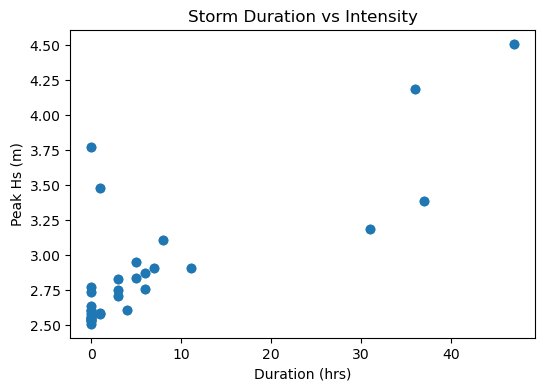

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(storm_df["duration_hours"], storm_df["peak_Hs"])
plt.xlabel("Duration (hrs)")
plt.ylabel("Peak Hs (m)")
plt.title("Storm Duration vs Intensity")
plt.show()


In [34]:
storm_df_clean = storm_df.dropna(subset=["mean_Tp", "mean_direction"]).copy()


In [36]:
from sklearn.preprocessing import StandardScaler

features = ["peak_Hs", "duration_hours", "mean_Tp", "mean_direction"]
X = storm_df_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [37]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
storm_df_clean["cluster"] = kmeans.fit_predict(X_scaled)
storm_df_clean.head()


C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,start,end,duration_hours,peak_Hs,mean_Hs,mean_Tp,mean_direction,cluster
32,2024-06-13 05:40:00+00:00,2024-06-13 08:40:00+00:00,3.0,2.71,2.582500,11.380000,103.013000,0
33,2024-06-14 16:40:00+00:00,2024-06-14 22:40:00+00:00,6.0,2.87,2.770000,10.565714,66.777571,0
34,2024-06-15 00:40:00+00:00,2024-06-15 06:40:00+00:00,6.0,2.76,2.648571,11.217143,58.843857,0
35,2024-06-25 23:45:00+00:00,2024-06-27 12:45:00+00:00,37.0,3.39,2.933947,13.002105,69.408921,1
36,2024-06-27 14:45:00+00:00,2024-06-27 19:45:00+00:00,5.0,2.95,2.778333,12.800000,76.310833,0


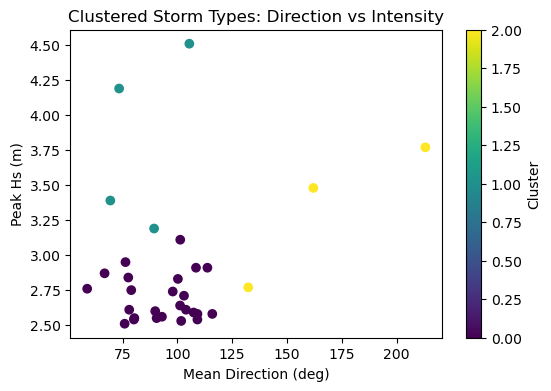

In [38]:
plt.figure(figsize=(6,4))
scatter = plt.scatter(storm_df_clean["mean_direction"], storm_df_clean["peak_Hs"],
                      c=storm_df_clean["cluster"], cmap="viridis")
plt.xlabel("Mean Direction (deg)")
plt.ylabel("Peak Hs (m)")
plt.title("Clustered Storm Types: Direction vs Intensity")
plt.colorbar(scatter, label="Cluster")
plt.show()
